# AIC-144 MBO Profile Comparison: Single Foil vs Two Foils

Compare depth-dose profiles from:
- **Single foil**: Rotated single detector (2025-11-25)
- **Two foils**: Merged adjacent detectors (2025-10-09)

Alignment: maximum at 24 mm, scaled to 5 Gy at X = 0 mm

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

# Configuration
BASE_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144")
SINGLE_FILE = BASE_PATH / "2025-11-25" / "mbo_aic144_single_foil_rotated.npz"
DOUBLE_FILE = BASE_PATH / "2025-10-09" / "profile_foils_1_2.npz"

MAX_TARGET_MM = 24.0  # Target position for maximum
DOSE_AT_ZERO = 5.0    # Target dose at X=0 [Gy]

# Load data
single = np.load(SINGLE_FILE)
double = np.load(DOUBLE_FILE)

print("Single foil keys:", list(single.keys()))
print("Double foil keys:", list(double.keys()))

Single foil keys: ['image_rotated', 'image_rotated_smooth', 'profile_x_mm', 'profile_values', 'rotation_angle_deg', 'pixel_size_mm', 'circle_center_x_mm', 'circle_center_y_mm', 'circle_radius_mm']
Double foil keys: ['x_mm', 'profile_opt_smooth', 'profile_y_min_mm', 'profile_y_max_mm', 'smoothing_sigma_px', 'pixel_size_mm']


In [7]:
# Extract profiles
x_single, y_single = single['profile_x_mm'], single['profile_values']
x_double, y_double = double['x_mm'], double['profile_opt_smooth']

# Find maximum positions
max_idx_single = np.argmax(y_single)
max_idx_double = np.argmax(y_double)
max_x_single, max_x_double = x_single[max_idx_single], x_double[max_idx_double]

print(f"Single foil: max at X = {max_x_single:.2f} mm, value = {y_single[max_idx_single]:.1f}")
print(f"Double foil: max at X = {max_x_double:.2f} mm, value = {y_double[max_idx_double]:.1f}")

# Shift X so max is at 24 mm
x_single_shifted = x_single - max_x_single + MAX_TARGET_MM
x_double_shifted = x_double - max_x_double + MAX_TARGET_MM

print(f"\nAfter shift: both maxima at {MAX_TARGET_MM} mm")

Single foil: max at X = 49.95 mm, value = 1761.5
Double foil: max at X = 28.79 mm, value = 2480.4

After shift: both maxima at 24.0 mm


In [8]:
# Scale to get 5 Gy at X = 0 mm
# Interpolate to find value at X = 0
interp_single = interp1d(x_single_shifted, y_single, kind='linear', fill_value='extrapolate')
interp_double = interp1d(x_double_shifted, y_double, kind='linear', fill_value='extrapolate')

val_at_0_single = float(interp_single(0))
val_at_0_double = float(interp_double(0))

scale_single = DOSE_AT_ZERO / val_at_0_single
scale_double = DOSE_AT_ZERO / val_at_0_double

y_single_scaled = y_single * scale_single
y_double_scaled = y_double * scale_double

print(f"Single foil: value at X=0: {val_at_0_single:.1f}, scale factor: {scale_single:.6f}")
print(f"Double foil: value at X=0: {val_at_0_double:.1f}, scale factor: {scale_double:.6f}")

Single foil: value at X=0: 666.6, scale factor: 0.007501
Double foil: value at X=0: 643.7, scale factor: 0.007767


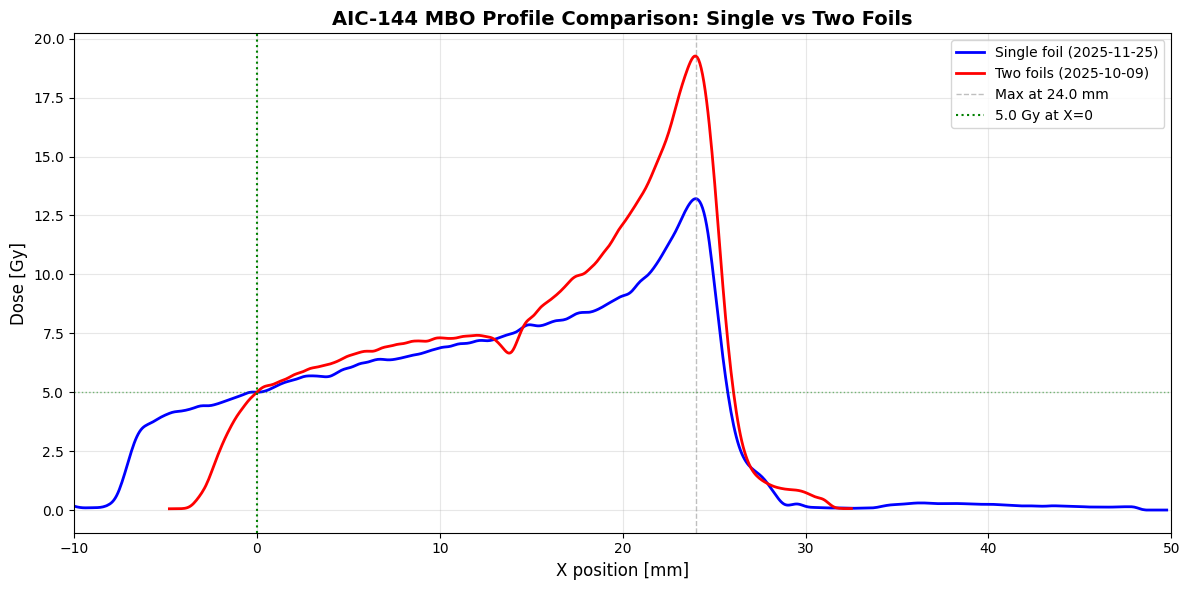

In [9]:
# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_single_shifted, y_single_scaled, 'b-', lw=2, label='Single foil (2025-11-25)')
ax.plot(x_double_shifted, y_double_scaled, 'r-', lw=2, label='Two foils (2025-10-09)')

ax.axvline(MAX_TARGET_MM, color='gray', ls='--', lw=1, alpha=0.5, label=f'Max at {MAX_TARGET_MM} mm')
ax.axvline(0, color='green', ls=':', lw=1.5, label=f'{DOSE_AT_ZERO} Gy at X=0')
ax.axhline(DOSE_AT_ZERO, color='green', ls=':', lw=1, alpha=0.5)

ax.set_xlabel('X position [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy]', fontsize=12)
ax.set_title('AIC-144 MBO Profile Comparison: Single vs Two Foils', fontsize=14, fontweight='bold')
ax.set_xlim(-10, 50)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

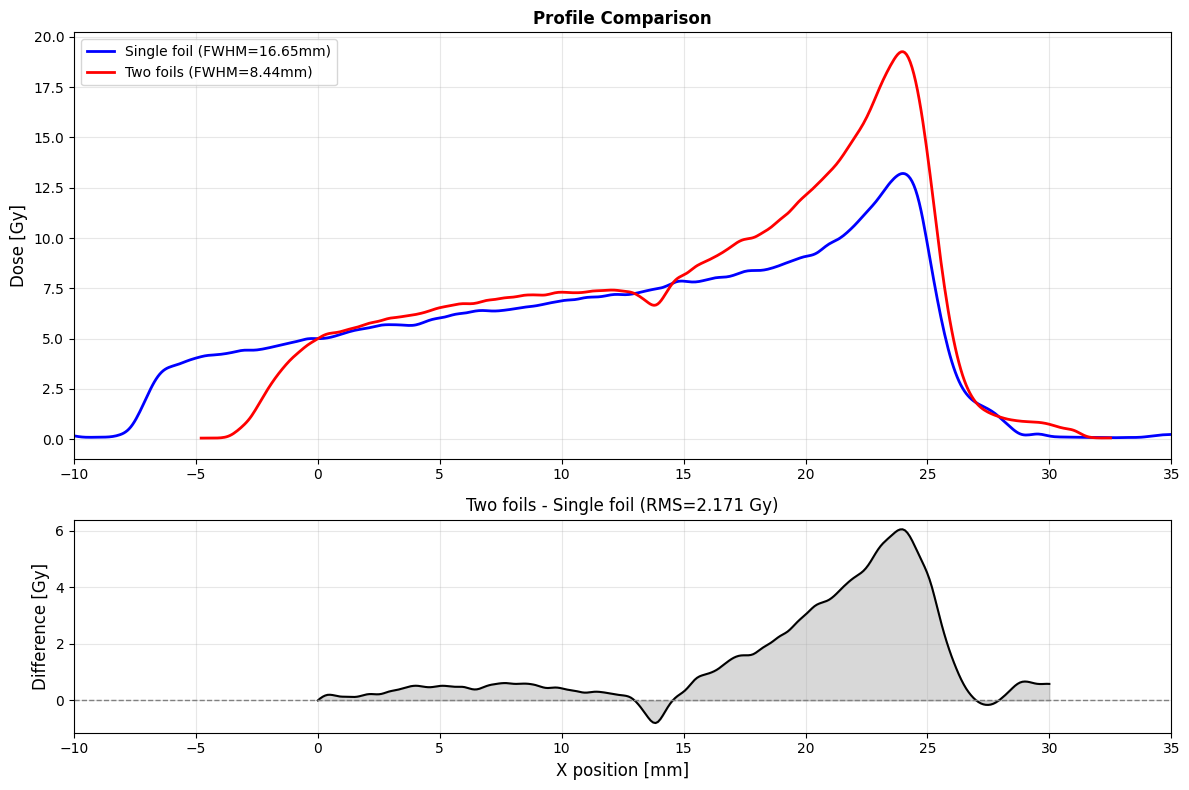


Summary:
  FWHM single: 16.65 mm
  FWHM double: 8.44 mm
  FWHM diff:   -8.21 mm
  RMS diff:    2.1712 Gy


In [13]:
# Calculate metrics and difference
def calc_fwhm(x, y):
    """Calculate FWHM."""
    y_max = y.max()
    half_max = y_max / 2
    above = y >= half_max
    trans = np.diff(above.astype(int))
    left = np.where(trans == 1)[0]
    right = np.where(trans == -1)[0]
    if len(left) > 0 and len(right) > 0:
        return x[right[-1]] - x[left[0]]
    return None

fwhm_single = calc_fwhm(x_single_shifted, y_single_scaled)
fwhm_double = calc_fwhm(x_double_shifted, y_double_scaled)

# Interpolate to common grid for difference calculation
x_common = np.linspace(0, 30, 300)
y_single_interp = interp1d(x_single_shifted, y_single_scaled, fill_value='extrapolate')(x_common)
y_double_interp = interp1d(x_double_shifted, y_double_scaled, fill_value='extrapolate')(x_common)
diff = y_double_interp - y_single_interp

# Plot difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

ax1.plot(x_single_shifted, y_single_scaled, 'b-', lw=2, label=f'Single foil (FWHM={fwhm_single:.2f}mm)')
ax1.plot(x_double_shifted, y_double_scaled, 'r-', lw=2, label=f'Two foils (FWHM={fwhm_double:.2f}mm)')
ax1.set_ylabel('Dose [Gy]', fontsize=12)
ax1.set_xlim(-10, 35)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Profile Comparison', fontsize=12, fontweight='bold')

ax2.plot(x_common, diff, 'k-', lw=1.5)
ax2.axhline(0, color='gray', ls='--', lw=1)
ax2.fill_between(x_common, diff, 0, alpha=0.3, color='gray')
ax2.set_xlabel('X position [mm]', fontsize=12)
ax2.set_ylabel('Difference [Gy]', fontsize=12)
ax2.set_xlim(-10, 35)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Two foils - Single foil (RMS={np.sqrt(np.mean(diff**2)):.3f} Gy)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  FWHM single: {fwhm_single:.2f} mm")
print(f"  FWHM double: {fwhm_double:.2f} mm")
print(f"  FWHM diff:   {fwhm_double - fwhm_single:.2f} mm")
print(f"  RMS diff:    {np.sqrt(np.mean(diff**2)):.4f} Gy")